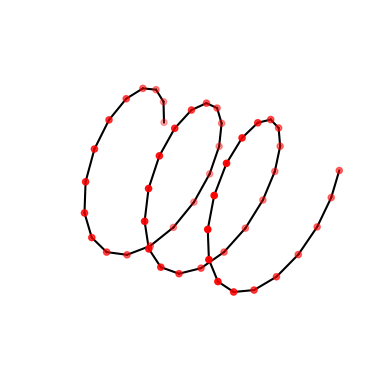

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=1200,
                            youngs_rod=1e8,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=25,
                                  total_time=0.2,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()

geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')
# geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n11.txt')


# env.add_force('gravity', g=np.array([10, 0.0, 0.0]))
env.add_force('pointForces', point_force_node_indices=[geo.nodes.shape[0]-1], 
              point_force_vectors=[np.array([120.0, 0.0, 0.0])])
# env.add_force('damping', eta=10)

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
fixed_points = np.array([0]) # fix the first node
robot = robot.fix_nodes(fixed_points)
stepper = dismech.ImplicitEulerTimeStepper(robot)
robots, t_arr, f_norms = stepper.simulate()
robots_with_robot0 = [robot] + robots
t_arr = [0.0] + t_arr
qs = np.stack([robot.state.q for robot in robots_with_robot0])
vs = np.stack([robot.state.u for robot in robots_with_robot0])
t_arr = np.array(t_arr)

iter: 1, error: 120.000
iter: 2, error: 134055.737
iter: 3, error: 1429.022
iter: 4, error: 8416.229
iter: 5, error: 947.725
iter: 6, error: 545.989
iter: 7, error: 149.503
iter: 8, error: 250.299
iter: 9, error: 23.984
iter: 10, error: 152.363
iter: 11, error: 2.413
iter: 12, error: 6.756
iter: 13, error: 0.078
current_time:  0.01
iter: 1, error: 48.902
iter: 2, error: 3287.818
iter: 3, error: 121.498
iter: 4, error: 464.613
iter: 5, error: 40.467
iter: 6, error: 121.244
iter: 7, error: 7.476
iter: 8, error: 29.204
iter: 9, error: 0.777
iter: 10, error: 0.239
current_time:  0.02
iter: 1, error: 45.509
iter: 2, error: 2769.666
iter: 3, error: 191.347
iter: 4, error: 356.877
iter: 5, error: 12.226
iter: 6, error: 3.424
iter: 7, error: 0.002
current_time:  0.03
iter: 1, error: 23.837
iter: 2, error: 22.260
iter: 3, error: 3.945
iter: 4, error: 0.049
current_time:  0.04
iter: 1, error: 7.360
iter: 2, error: 11.536
iter: 3, error: 0.237
current_time:  0.05
iter: 1, error: 1.395
iter: 2, er

In [3]:
options = dismech.AnimationOptions(title='Helix (N=50)', plot_step=1)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

22


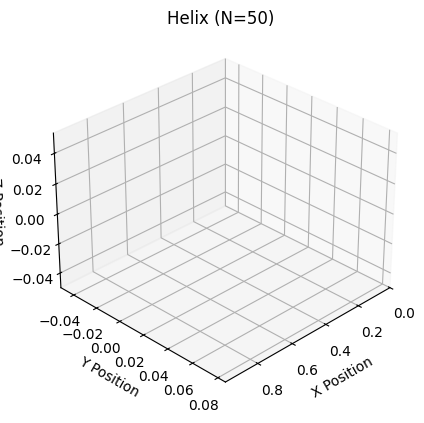

In [4]:
ani = dismech.get_animation(robot, t_arr, qs, options)
ani.save('slinky_pulling.gif')

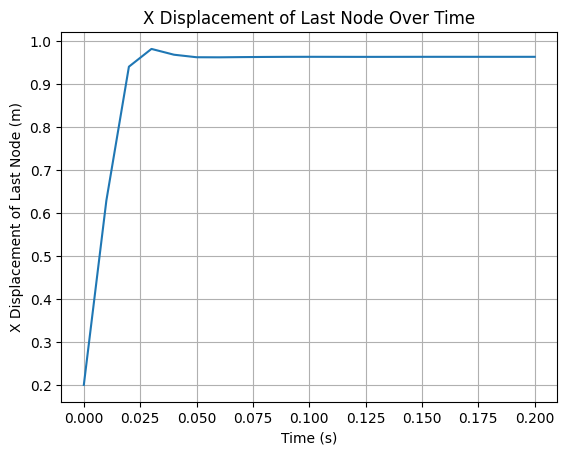

In [5]:
# plot the x discplacement of the last node over time
import matplotlib.pyplot as plt
last_node_x_disp = qs[:, robot.end_node_dof_index-3] # x is the first dof of the last node
plt.plot(t_arr, last_node_x_disp)
plt.xlabel('Time (s)')
plt.ylabel('X Displacement of Last Node (m)')
plt.title('X Displacement of Last Node Over Time')
plt.grid()

In [6]:
# # get centroid trajectory (correct)
# T = qs.shape[0]

# qs_nodes = qs[:, :robot.n_nodes * 3]                    # (T, 3*n)
# nodes = qs_nodes.reshape(T, robot.n_nodes, 3)           # (T, n, 3)  where last dim is (x,y,z)
# centroid_traj = nodes.mean(axis=1)                      # (T, 3)

# vs_nodes = vs[:, :robot.n_nodes * 3]
# nodes_vel = vs_nodes.reshape(T, robot.n_nodes, 3)       # (T, n, 3)
# centroid_vel = nodes_vel.mean(axis=1)                   # (T, 3)

# # slinky length from last node x-coordinate (or use a known constant L if you have it)
# slinky_len = nodes[-1, -1, 0]                           # x of last node at final time

# start_block = np.tile([0.0, 0.0, 0.0], (T, 1))          # (T, 3)
# end_block   = np.tile([slinky_len, 0.0, 0.0], (T, 1))   # (T, 3)

# centerline_nodes_traj = np.hstack([start_block, centroid_traj, end_block])  # (T, 9)

# centerline_edges_traj = np.zeros((T, 2))                # 3 nodes -> 2 edges

# centerline_node_vel = np.hstack([
#     np.zeros((T, 3)),
#     centroid_vel,
#     np.zeros((T, 3))
# ])                                                      # (T, 9)

# centerline_angvel = np.zeros((T, 2))                    # 2 edges

# xs_centerline = np.hstack([
#     centerline_nodes_traj,
#     centerline_edges_traj,
#     centerline_node_vel,
#     centerline_angvel
# ])                                                      # (T, 9+2+9+2) = (T, 22)

# x = qs_nodes[:, 0::3]
# y = qs_nodes[:, 1::3]
# z = qs_nodes[:, 2::3]
# centroid_alt = np.stack([x.mean(axis=1), y.mean(axis=1), z.mean(axis=1)], axis=1)

# print("max abs diff:", np.max(np.abs(centroid_traj - centroid_alt)))

In [7]:
# get centroid trajectory (correct)
T = qs.shape[0]

qs_nodes = qs[:, :robot.n_nodes * 3]                    # (T, 3*n)
nodes = qs_nodes.reshape(T, robot.n_nodes, 3)           # (T, n, 3)  where last dim is (x,y,z)
end_traj = nodes[:, -1, :]                      # (T, 3)
end_traj[:, 1:] = 0.0                          # zero out y and z to get pure x trajectory

vs_nodes = vs[:, :robot.n_nodes * 3]
nodes_vel = vs_nodes.reshape(T, robot.n_nodes, 3)       # (T, n, 3)
end_vel = nodes_vel[:, -1, :]                   # (T, 3)
end_vel[:, 1:] = 0.0                          # zero out y and z to get pure x velocity

# slinky length from last node x-coordinate (or use a known constant L if you have it)
slinky_len = nodes[-1, -1, 0]                           # x of last node at final time

start_block = np.tile([0.0, 0.0, 0.0], (T, 1))          # (T, 3)

centerline_nodes_traj = np.hstack([start_block, end_traj])  # (T, 6)

centerline_edges_traj = np.zeros((T, 1))                # 3 nodes -> 2 edges

centerline_node_vel = np.hstack([
    np.zeros((T, 3)),
    end_vel,
])                                                      # (T, 6)

centerline_angvel = np.zeros((T, 1))                    # 2 edges

xs_centerline = np.hstack([
    centerline_nodes_traj,
    centerline_edges_traj,
    centerline_node_vel,
    centerline_angvel
])                                                      # (T, 6+1+6+1) = (T, 14)


In [8]:

print("centerline state shape:", xs_centerline.shape)
print("centerline_nodes_traj[0], centerline_nodes_traj[-1]:", centerline_nodes_traj[0], centerline_nodes_traj[-1])

np.savez("slinky_pulling_centerline_truth.npz", xs_centerline=xs_centerline)

centerline state shape: (22, 14)
centerline_nodes_traj[0], centerline_nodes_traj[-1]: [0.  0.  0.  0.2 0.  0. ] [0.         0.         0.         0.96346941 0.         0.        ]
